# Exploratory Data Analysis (EDA) & Feature Engineering
**Project:** AI Earthquake Emergency Response System

**Objective:**
This notebook conducts a rigorous Exploratory Data Analysis (EDA) on our historical seismic dataset. The goal is to clean missing values, engineer our primary target variable (`Disaster_Urgency`), and generate analytical visualizations to justify our Machine Learning strategy.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams.update({'figure.dpi': 300})

# 1. Load the Dataset
df = pd.read_csv('../data/earthquake_data.csv')
print(f"Initial Dataset Shape: {df.shape}")

# 2. Handle Missing Values Based on Project Strategy
# We impute 'alert' with 'none' as missing usually implies baseline risk[cite: 207].
if 'alert' in df.columns:
    df['alert'] = df['alert'].fillna('none')

# Missing continent/country often indicates oceanic earthquakes[cite: 208]. 
# We impute with 'Oceanic/Unknown' to preserve valuable seismic data[cite: 209].
if 'continent' in df.columns:
    df['continent'] = df['continent'].fillna('Oceanic/Unknown')
if 'country' in df.columns:
    df['country'] = df['country'].fillna('Oceanic/Unknown')

# Create 'is_oceanic' binary feature [cite: 211]
df['is_oceanic'] = np.where((df['country'] == 'Oceanic/Unknown') | (df['tsunami'] == 1), 1, 0)

# Drop any remaining trace NaNs in critical coordinate columns [cite: 210]
df.dropna(subset=['latitude', 'longitude', 'magnitude', 'depth'], inplace=True)

Initial Dataset Shape: (782, 19)


In [11]:
# 3. Extract Temporal Features (Cyclical Encoding)
# Converting standard datetime strings into cyclical mathematical features
if 'date_time' in df.columns: # Adjust column name to match your dataset (e.g., 'time' or 'date')
    df['parsed_date'] = pd.to_datetime(df['date_time'], errors='coerce')
    df.dropna(subset=['parsed_date'], inplace=True)
    
    df['year'] = df['parsed_date'].dt.year
    df['month'] = df['parsed_date'].dt.month
    
    # Cyclical encoding for months
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Drop the original string date column
    df.drop(columns=['parsed_date', 'date_time', 'month'], inplace=True)

# 4. Engineer the Multiclass Target: Disaster_Urgency [cite: 199]
def categorize_urgency(sig):
    if sig < 400: return 'LOW'
    elif sig < 800: return 'MEDIUM'
    elif sig < 1200: return 'HIGH'
    else: return 'CRITICAL'

df['Disaster_Urgency'] = df['sig'].apply(categorize_urgency)
urgency_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
df['Disaster_Urgency'] = pd.Categorical(df['Disaster_Urgency'], categories=urgency_order, ordered=True)

# 5. Discard Sparse Categorical Properties
# Dropping high-cardinality text columns that bloat the model
cols_to_drop = ['title', 'location', 'net', 'magType'] 
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print(f"Cleaned Dataset Shape: {df.shape}")
df.head()

Cleaned Dataset Shape: (782, 19)


,magnitude,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,depth,latitude,longitude,continent,country,is_oceanic,year,month_sin,month_cos,Disaster_Urgency
0,7.0,8,7,green,1,768,117,0.509,17.0,14.000,-9.7963,159.596,Oceania,Solomon Islands,1,2022,-0.5,0.866025,MEDIUM
1,6.9,4,4,green,0,735,99,2.229,34.0,25.000,-4.9559,100.738,Oceanic/Unknown,Oceanic/Unknown,1,2022,-0.5,0.866025,MEDIUM
2,7.0,3,3,green,1,755,147,3.125,18.0,579.000,-20.0508,-178.346,Oceania,Fiji,1,2022,-0.5,0.866025,MEDIUM
3,7.3,5,5,green,1,833,149,1.865,21.0,37.000,-19.2918,-172.129,Oceanic/Unknown,Oceanic/Unknown,1,2022,-0.5,0.866025,HIGH
4,6.6,0,2,green,1,670,131,4.998,27.0,624.464,-25.5948,178.278,Oceanic/Unknown,Oceanic/Unknown,1,2022,-0.5,0.866025,MEDIUM


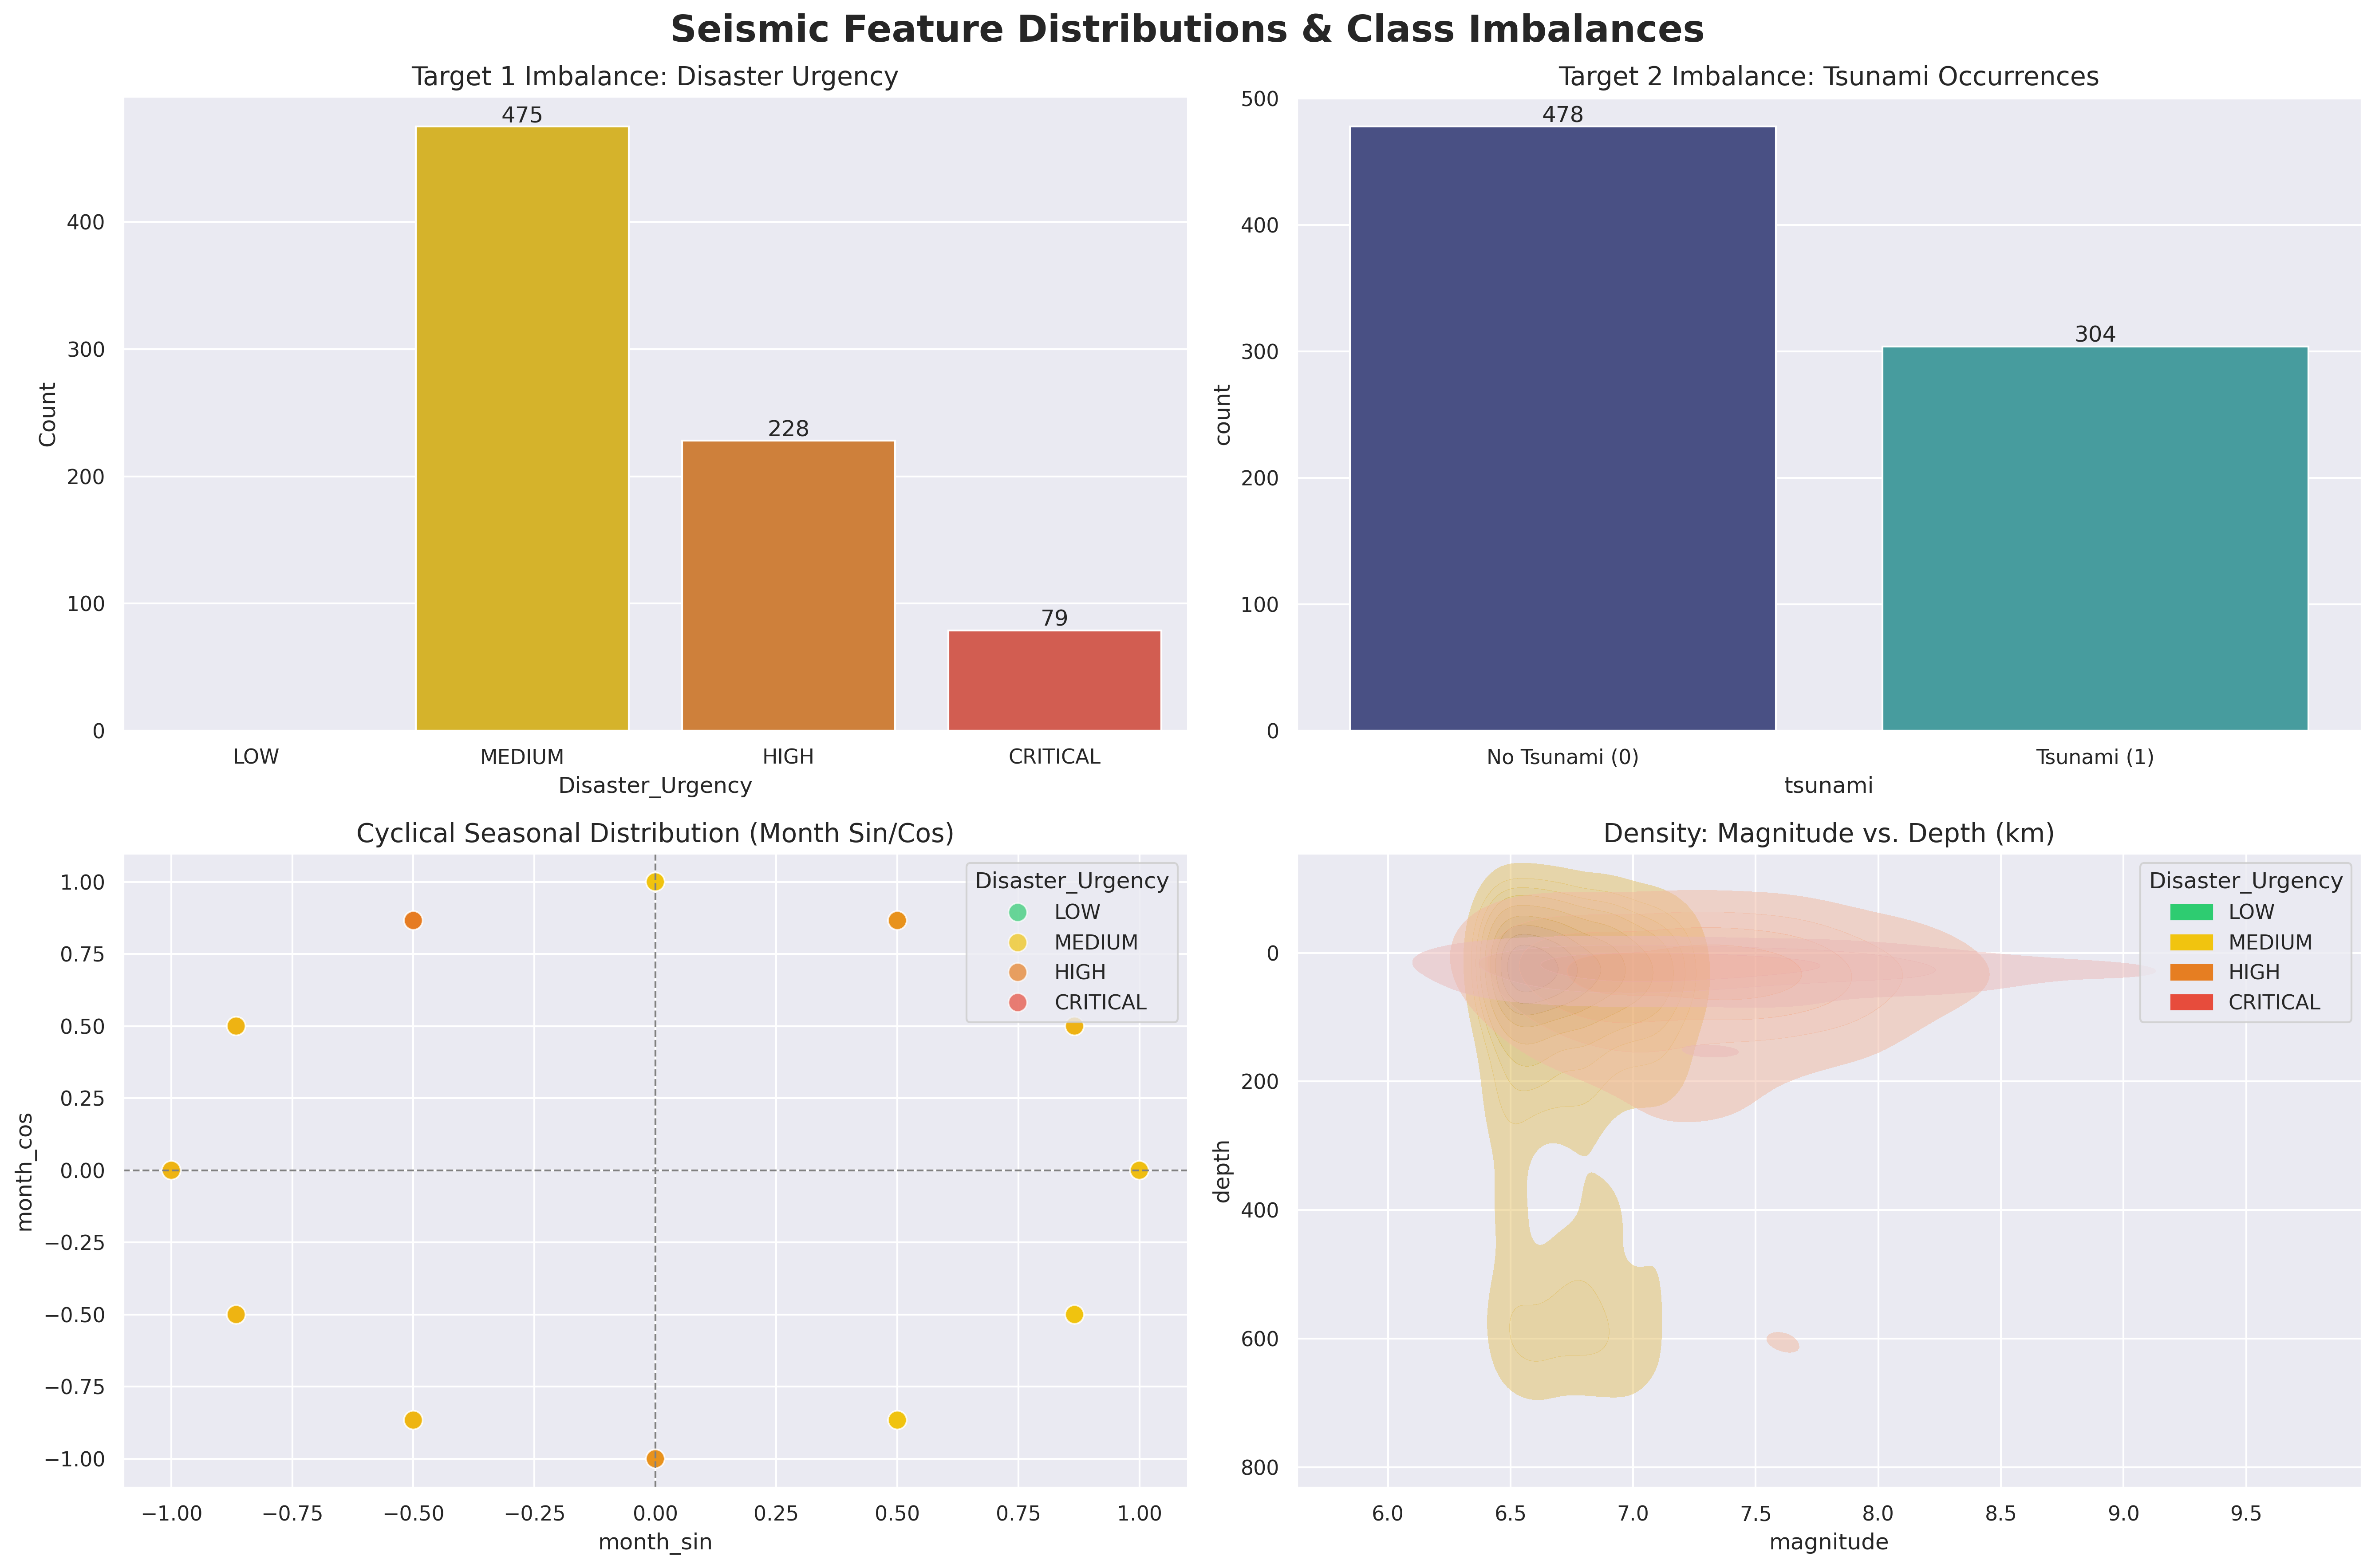

In [12]:
# --- DEEP EXPLORATORY DATA ANALYSIS ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Seismic Feature Distributions & Class Imbalances", fontsize=20, fontweight='bold', y=0.98)

# Chart 1: The Extreme Class Imbalance (Threat Level)
sns.countplot(ax=axes[0, 0], data=df, x='Disaster_Urgency', palette=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
axes[0, 0].set_title("Target 1 Imbalance: Disaster Urgency", fontsize=14)
axes[0, 0].set_ylabel("Count")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

# Chart 2: The Extreme Class Imbalance (Tsunami)
sns.countplot(ax=axes[0, 1], data=df, x='tsunami', palette='mako')
axes[0, 1].set_title("Target 2 Imbalance: Tsunami Occurrences", fontsize=14)
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['No Tsunami (0)', 'Tsunami (1)'])
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

# Chart 3: Cyclical Temporal Distribution (Earthquakes over Months)
sns.scatterplot(ax=axes[1, 0], data=df, x='month_sin', y='month_cos', hue='Disaster_Urgency', 
                palette=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'], s=100, alpha=0.7)
axes[1, 0].set_title("Cyclical Seasonal Distribution (Month Sin/Cos)", fontsize=14)
axes[1, 0].axhline(0, color='grey', linestyle='--', linewidth=1)
axes[1, 0].axvline(0, color='grey', linestyle='--', linewidth=1)

# Chart 4: Magnitude vs Depth KDE Plot (Where do severe quakes happen?)
sns.kdeplot(ax=axes[1, 1], data=df, x='magnitude', y='depth', hue='Disaster_Urgency', 
            palette=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'], fill=True, alpha=0.5)
axes[1, 1].set_title("Density: Magnitude vs. Depth (km)", fontsize=14)
axes[1, 1].invert_yaxis() # Depth goes down

plt.tight_layout()
plt.show()

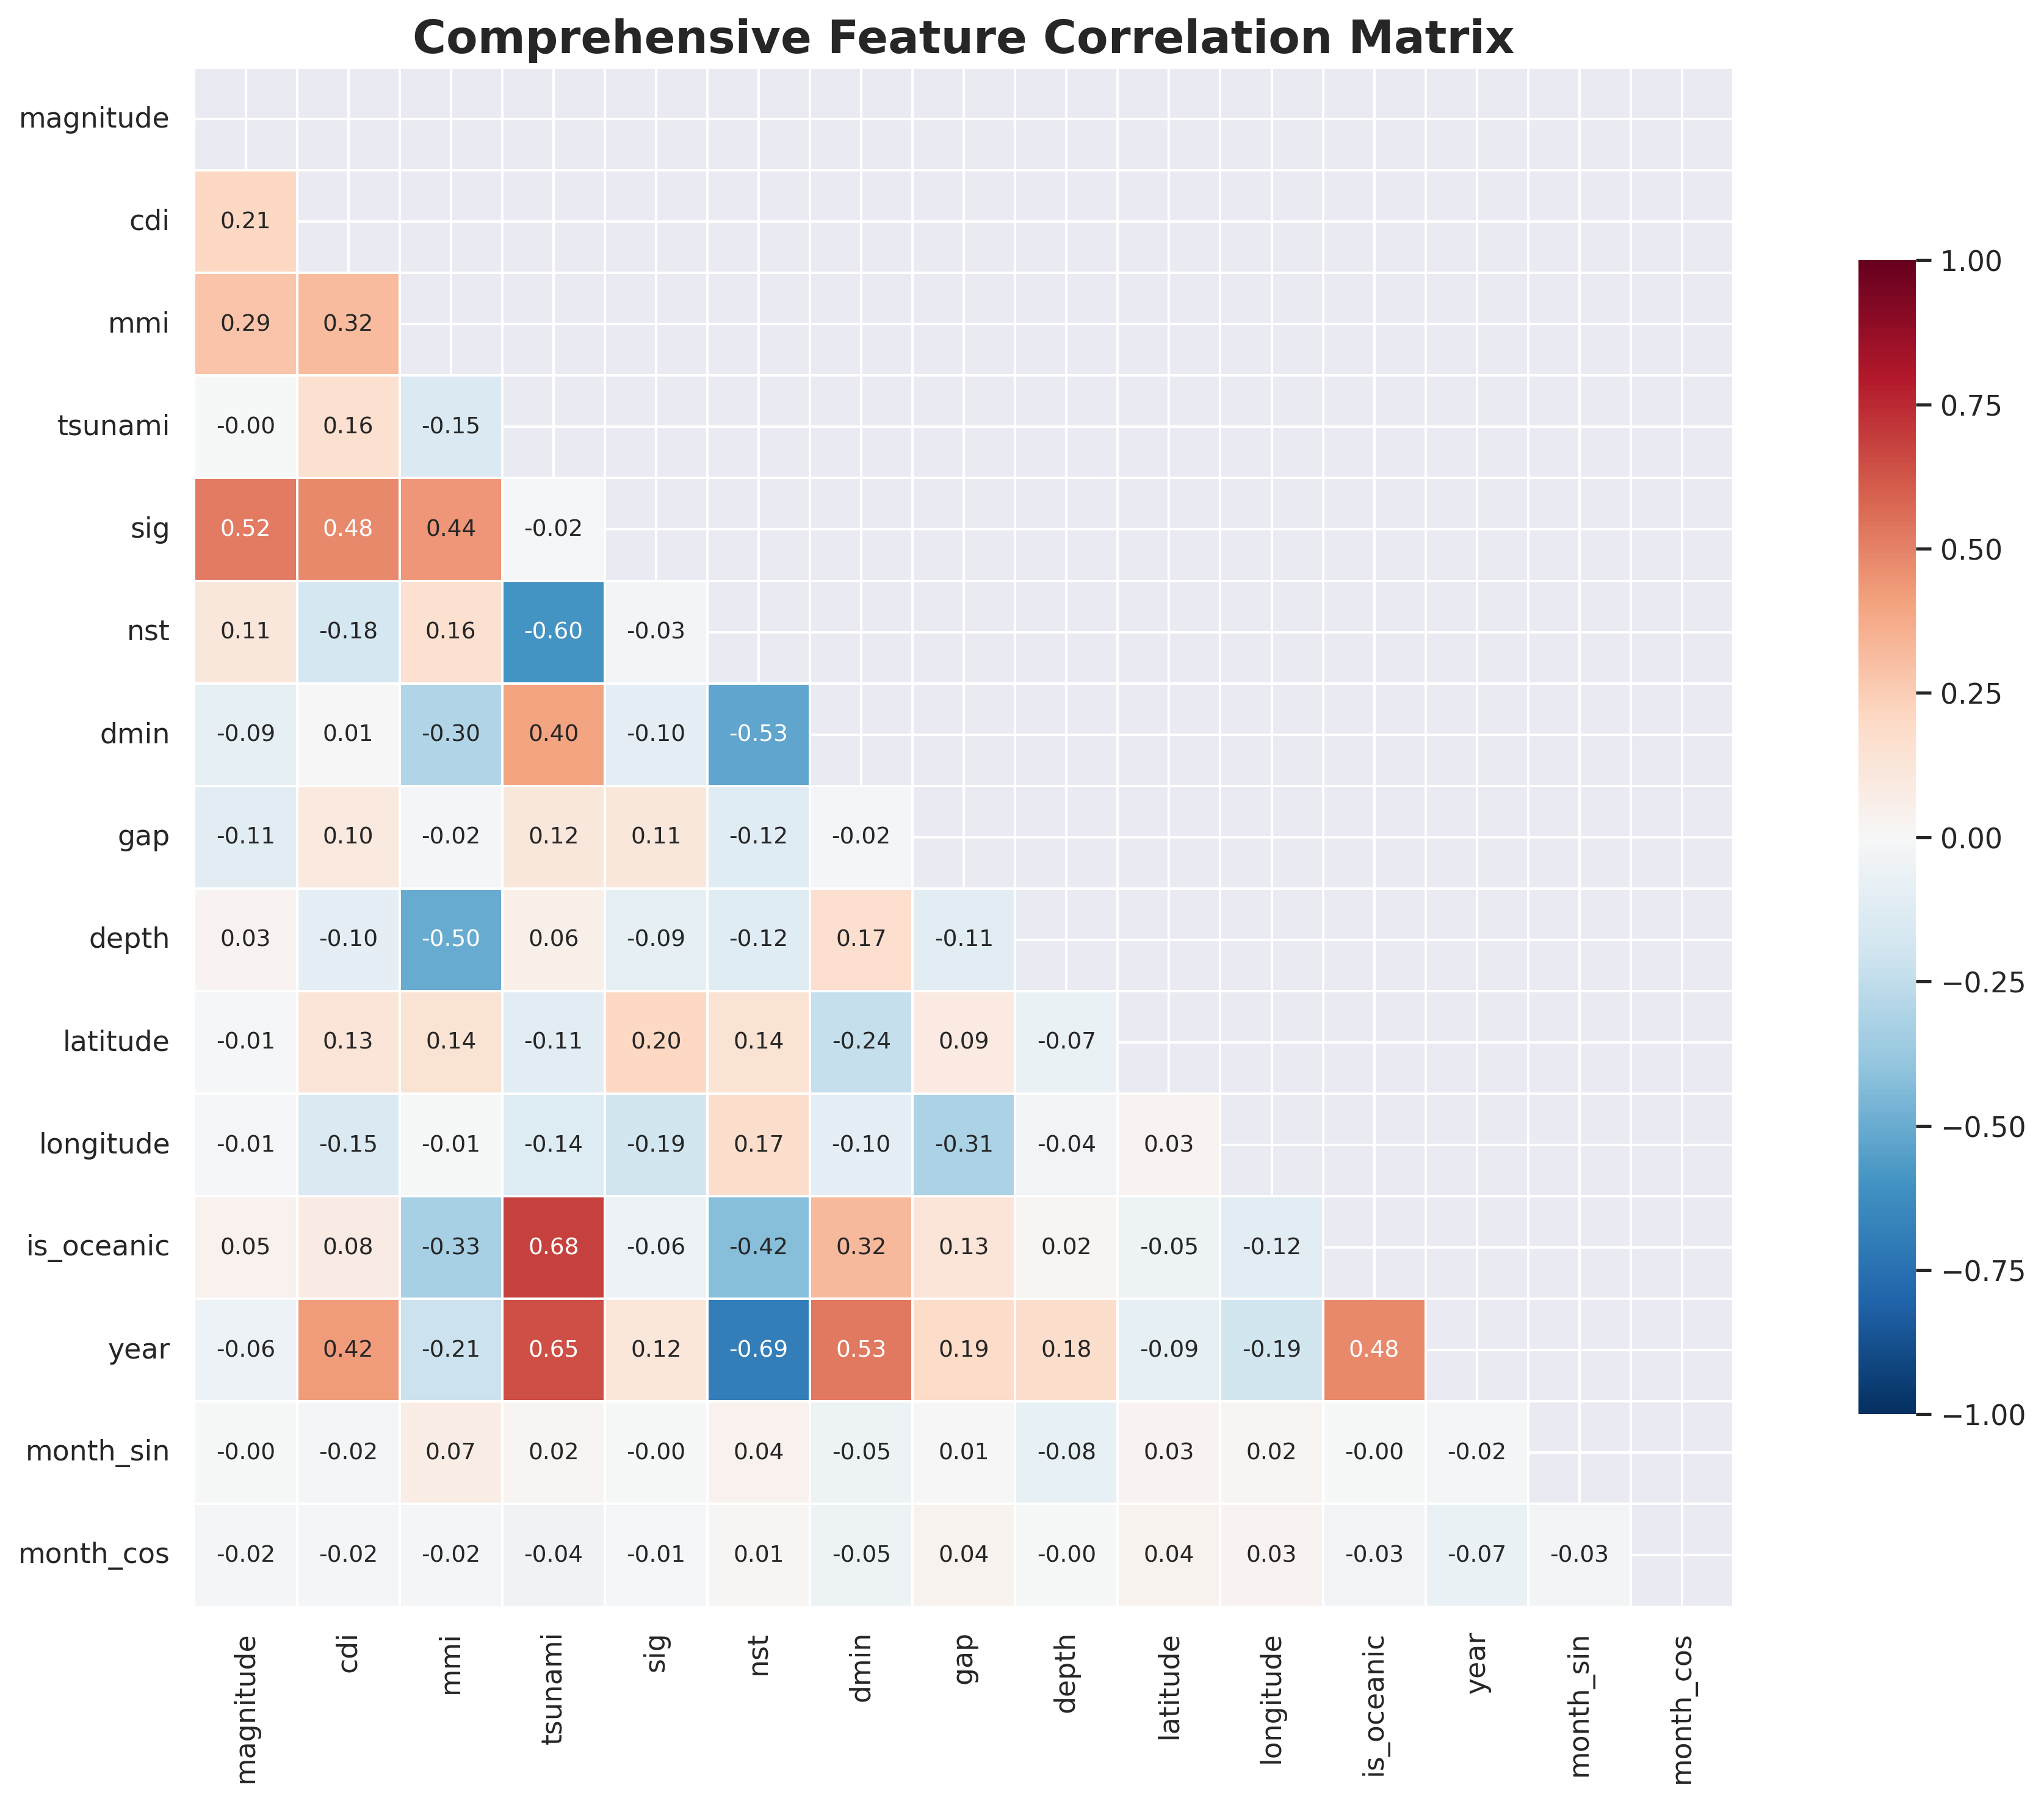

In [13]:
# --- ADVANCED CORRELATION ANALYSIS ---
# Filter for numeric columns to prevent errors
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .75}, annot_kws={"size": 9})

plt.title('Comprehensive Feature Correlation Matrix', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# --- PREVENTING DATA LEAKAGE: SPLIT BEFORE SCALING ---
# We isolate metric/geographical features for scaling
metric_features = ['latitude', 'longitude', 'magnitude', 'depth', 'cdi', 'mmi', 'sig', 'gap', 'dmin', 'year', 'month_sin', 'month_cos']

# Ensure all selected features exist in the dataframe
metric_features = [f for f in metric_features if f in df.columns]

# Define Features (X) and Targets (y)
X = df[metric_features + ['is_oceanic']] # Include our engineered binary
y_threat = df['Disaster_Urgency']
y_tsunami = df['tsunami']

# 1. Train/Test Split (Stratify ensures representation of minority classes) [cite: 238]
X_train, X_test, y_train_th, y_test_th = train_test_split(X, y_threat, test_size=0.2, random_state=42, stratify=y_threat)
_, _, y_train_ts, y_test_ts = train_test_split(X, y_tsunami, test_size=0.2, random_state=42, stratify=y_tsunami)

# 2. Standard Scaling 
# Fitting the scaler ONLY on the training data prevents information leakage[cite: 236].
scaler = StandardScaler()

# Scale only the continuous metric features
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[metric_features] = scaler.fit_transform(X_train[metric_features])
X_test_scaled[metric_features] = scaler.transform(X_test[metric_features])

print("Data Split & Scaled Successfully.")
print(f"Training Set: {X_train_scaled.shape[0]} records")
print(f"Testing Set: {X_test_scaled.shape[0]} records")

Data Split & Scaled Successfully.
Training Set: 625 records
Testing Set: 157 records


In [15]:
# --- HANDLING EXTREME CLASS IMBALANCES WITH SMOTE ---
# Applied strictly to the training sets to prevent bleeding synthetic data into validation[cite: 236].

smote = SMOTE(random_state=42)

# 1. SMOTE for Multiclass Threat Target
print("--- DISASTER URGENCY (THREAT) IMBALANCE ---")
print("Before SMOTE:")
print(y_train_th.value_counts())

X_train_th_sm, y_train_th_sm = smote.fit_resample(X_train_scaled, y_train_th)

print("\nAfter SMOTE:")
print(y_train_th_sm.value_counts())

# 2. SMOTE for Binary Tsunami Target
print("\n--- TSUNAMI IMBALANCE ---")
print("Before SMOTE:")
print(y_train_ts.value_counts())

X_train_ts_sm, y_train_ts_sm = smote.fit_resample(X_train_scaled, y_train_ts)

print("\nAfter SMOTE:")
print(y_train_ts_sm.value_counts())

# The data is now perfectly formatted, scaled, and balanced for model training.

--- DISASTER URGENCY (THREAT) IMBALANCE ---
Before SMOTE:
Disaster_Urgency
MEDIUM      380
HIGH        182
CRITICAL     63
LOW           0
Name: count, dtype: int64

After SMOTE:
Disaster_Urgency
MEDIUM      380
HIGH        380
CRITICAL    380
LOW           0
Name: count, dtype: int64

--- TSUNAMI IMBALANCE ---
Before SMOTE:
tsunami
0    382
1    243
Name: count, dtype: int64

After SMOTE:
tsunami
0    382
1    382
Name: count, dtype: int64


In [16]:
# CHART 4: Geospatial Heatmap
# This proves the existence of "Seismic Hotspots" (The Ring of Fire) to justify your K-Means clustering.

print("Generating Interactive Global Seismic Heatmap...")
map_center = [df['latitude'].mean(), df['longitude'].mean()]
world_map = folium.Map(location=map_center, zoom_start=2, tiles='CartoDB dark_matter')

# Filter for medium to severe earthquakes for a cleaner map
severe_quakes = df[df['magnitude'] >= 5.5]

heat_data = severe_quakes[['latitude', 'longitude', 'magnitude']].values.tolist()

plugins.HeatMap(
    heat_data, 
    min_opacity=0.4,
    radius=15, 
    blur=10, 
    max_zoom=1
).add_to(world_map)

# Display the map in the notebook
world_map

Generating Interactive Global Seismic Heatmap...
